# Notebook 11 - Per-minibacia daily forcing: rainfall + PET

MGB-SA runs a **daily water balance for every minibacia**. This notebook turns the collected
observations into the two fields the model consumes.

| Field | Source | Why this source |
|---|---|---|
| **Rainfall** (mm/day) | IDEAM conventional gauges, 294 stations | Selected in notebook 10: the automatic network under-catches ~31 % and leaves 63 % of the basin >30 km from a gauge |
| **PET** (mm/day) | ERA5-Land, FAO-56 Penman-Monteith | All five required variables are present (`t2m`, `d2m`, `ssrd`, `u10/v10`, `sp`), so full physics rather than a temperature-only proxy |

These are not two versions of the same thing - they are the two sides of the water balance:
rainfall is water in, PET is the atmospheric demand that takes water out. PET also dries the soil
between storms, which sets the antecedent moisture that decides how much of the *next* storm becomes
runoff - and therefore how much sediment MUSLE generates.

**This is the v1 baseline, deliberately gauge-only.** Notebook 10 showed CHIRPS reproduces the ENSO
contrast exactly (1.69x vs 1.69x) but damps daily extremes (P99 ratio 0.74). Section 6 measures the
skill of gauge-only interpolation so that adding CHIRPS in v2 becomes a *measured* improvement rather
than an assumed one.

**The limitation carried explicitly throughout:** 17 % of basin area lies more than 30 km from any
gauge, concentrated in the high headwaters that generate most of the sediment. Section 5 flags every
minibacia so this stays visible instead of disappearing into a CSV.

In [1]:
import glob, pathlib
import numpy as np, pandas as pd, rasterio
import matplotlib.pyplot as plt
from scipy import ndimage
%matplotlib inline
plt.rcParams.update({'figure.dpi': 96, 'axes.grid': False})

REPO = None
for b in [pathlib.Path.cwd()] + list(pathlib.Path.cwd().parents):
    if (b/'data'/'processed'/'minibacias.tif').exists():
        REPO = b; break
proc = REPO/'data'/'processed'; clim = REPO/'data'/'raw'/'climate'

# repaired dataset: 55 zero-suppressed stations fixed by
# src/repair_precip_zero_suppression.py (see notebook 10, section 1)
gauges = (pd.read_csv(proc/'precip_gauges_inventory_qc.csv', dtype={'code': str})
            .dropna(subset=['lat', 'lon']).reset_index(drop=True))
daily = pd.read_csv(proc/'precip_gauges_daily_qc.csv', dtype={'code': str}).dropna(subset=['precip_mm'])
daily['date'] = pd.to_datetime(daily['date'])
mb = pd.read_csv(proc/'minibacias.csv')

with rasterio.open(proc/'minibacias.tif') as src:
    lab = src.read(1); tr = src.transform; bnds = src.bounds
EXT = (bnds.left, bnds.right, bnds.bottom, bnds.top)

def to_grid(ids, vals):
    '''Paint per-minibacia values onto the label raster for mapping.'''
    lut = np.full(int(lab.max())+1, np.nan, dtype='float32')
    lut[np.asarray(ids, dtype=int)] = np.asarray(vals, dtype='float32')
    g = lut[lab]
    return np.where(lab == 0, np.nan, g)

print(f'gauges       : {len(gauges)}')
print(f'station-days : {len(daily):,}   {daily.date.min().date()} -> {daily.date.max().date()}')
print(f'minibacias   : {len(mb)}   total area {mb.area_km2.sum():,.0f} km2')

gauges       : 294
station-days : 808,537   2008-01-01 -> 2018-12-31
minibacias   : 8672   total area 257,097 km2


## 1 - Quality control of the gauge input

Before interpolating anything, look at what the record actually contains. `build_precip_gauges.py`
already de-duplicated overlapping station-days, screened values to 0-400 mm/day, dropped flatline and
ultra-sparse stations, filtered out-of-basin departments and backfilled coordinates. Three checks it
did **not** do are done here:

1. **Availability** - where the gaps are in time and across stations. A single "% filled" number
   hides whether gaps are scattered or whole years missing.
2. **Double-mass homogeneity** - cumulative station rainfall against the cumulative basin mean. A
   straight line means a stable record; a *kink* means the station moved, the observer changed, or the
   instrument was replaced. Those breaks bias any correction fitted across them.
3. **Spatial consistency** - station-days that disagree violently with their neighbours. Deferred to
   section 6, where the leave-one-out prediction needed for the test already exists.

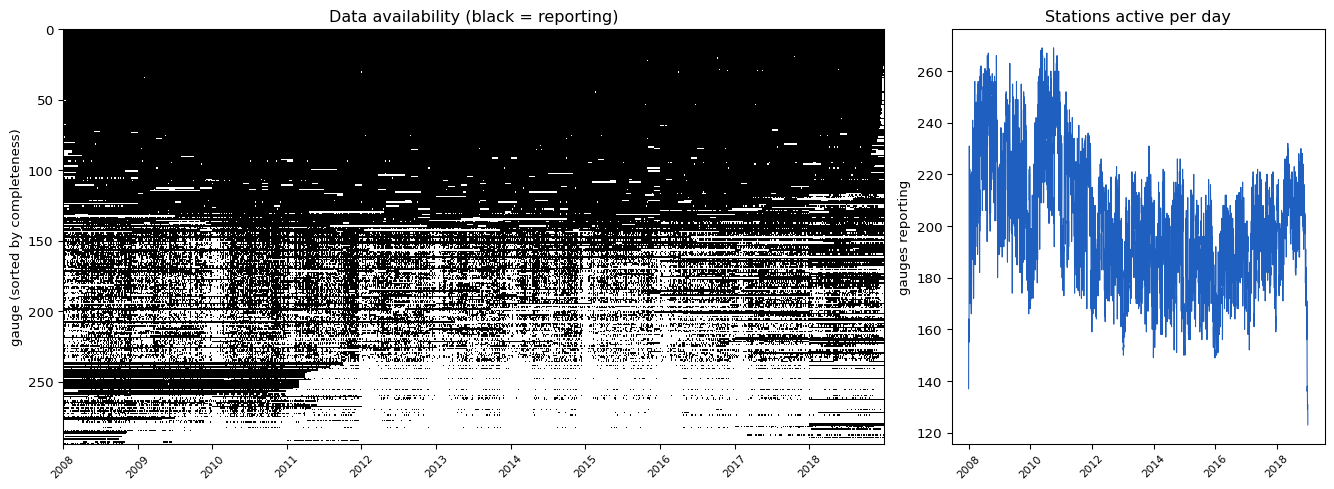

matrix 4018 days x 294 gauges | filled 68.4 %
  gauges reporting per day: median 200, min 123, max 269
  station record length   : median 3076 days of 4018


In [2]:
A = (daily.assign(one=1)
          .pivot_table(index='date', columns='code', values='one', aggfunc='max')
          .reindex(columns=gauges.code.values)
          .reindex(pd.date_range(daily.date.min(), daily.date.max(), freq='D')))
Amat = A.notna().values
order = np.argsort(-Amat.sum(0))            # densest stations first

fig, ax = plt.subplots(1, 2, figsize=(14, 5.2),
                       gridspec_kw={'width_ratios': [2.2, 1]})
ax[0].imshow(Amat[:, order].T, aspect='auto', cmap='Greys', interpolation='nearest',
             extent=[0, Amat.shape[0], len(gauges), 0])
yrs = pd.date_range(A.index.min(), A.index.max(), freq='YS')
ax[0].set_xticks([(y - A.index.min()).days for y in yrs])
ax[0].set_xticklabels([y.year for y in yrs], rotation=45, fontsize=8)
ax[0].set_ylabel('gauge (sorted by completeness)'); ax[0].set_title('Data availability (black = reporting)')
ax[1].plot(A.index, Amat.sum(1), lw=.8, color='#1f5fbf')
ax[1].set_ylabel('gauges reporting'); ax[1].set_title('Stations active per day')
ax[1].tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout(); plt.show()

print(f'matrix {Amat.shape[0]} days x {Amat.shape[1]} gauges | filled {100*Amat.mean():.1f} %')
print(f'  gauges reporting per day: median {int(np.median(Amat.sum(1)))}, '
      f'min {int(Amat.sum(1).min())}, max {int(Amat.sum(1).max())}')
print(f'  station record length   : median {int(np.median(Amat.sum(0)))} days '
      f'of {Amat.shape[0]}')

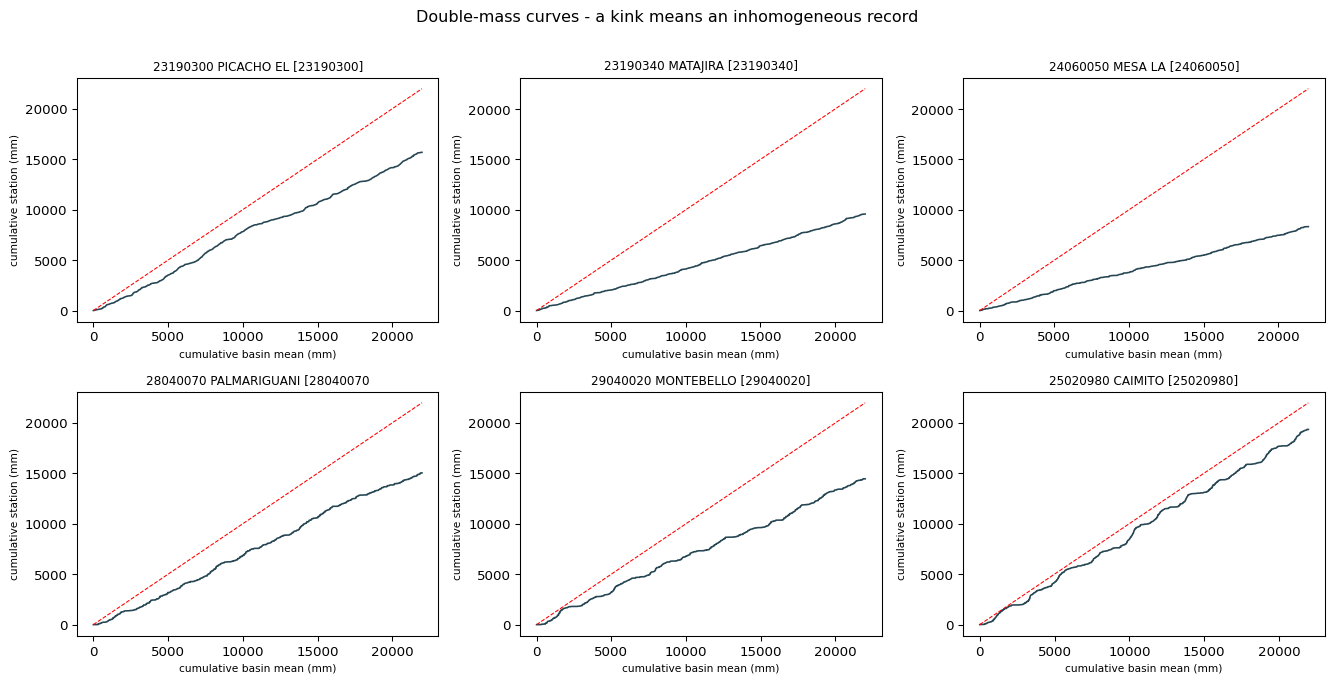

Straight lines => homogeneous. Slope != 1 is fine (local wetness); a change of slope is not.


In [3]:
# double-mass: cumulative station vs cumulative mean of all other stations
W = (daily.pivot_table(index='date', columns='code', values='precip_mm')
          .reindex(columns=gauges.code.values)
          .reindex(A.index))
longest = W.notna().sum().sort_values(ascending=False).head(6).index

fig, ax = plt.subplots(2, 3, figsize=(14, 7))
for a, code_ in zip(ax.ravel(), longest):
    sub = W[[c for c in W.columns if c != code_]].mean(1)
    m = W[code_].notna() & sub.notna()
    a.plot(sub[m].cumsum(), W.loc[m, code_].cumsum(), lw=1.2, color='#264653')
    lim = [0, max(sub[m].cumsum().max(), W.loc[m, code_].cumsum().max())]
    a.plot(lim, lim, 'r--', lw=.8)
    nm = str(gauges.loc[gauges.code == code_, 'name'].iloc[0])[:22]
    a.set_title(f'{code_} {nm}', fontsize=9)
    a.set_xlabel('cumulative basin mean (mm)', fontsize=8)
    a.set_ylabel('cumulative station (mm)', fontsize=8)
plt.suptitle('Double-mass curves - a kink means an inhomogeneous record', y=1.01)
plt.tight_layout(); plt.show()
print('Straight lines => homogeneous. Slope != 1 is fine (local wetness); a change of slope is not.')

## 2 - Minibacia centroids

The interpolation needs one target point per minibacia. `minibacias.tif` stores the minibacia ID per
pixel, so the centroid is the centre of mass of each labelled region, mapped to lon/lat through the
raster's affine transform.

Centroid rather than a full areal average: at 0.0067 deg (~740 m) pixels against minibacias averaging
~30 km2, and with gauges tens of kilometres apart, the interpolated field varies far more slowly than
a single minibacia's footprint. The centroid is the honest resolution of the input.

centroids: 8672 of 8672


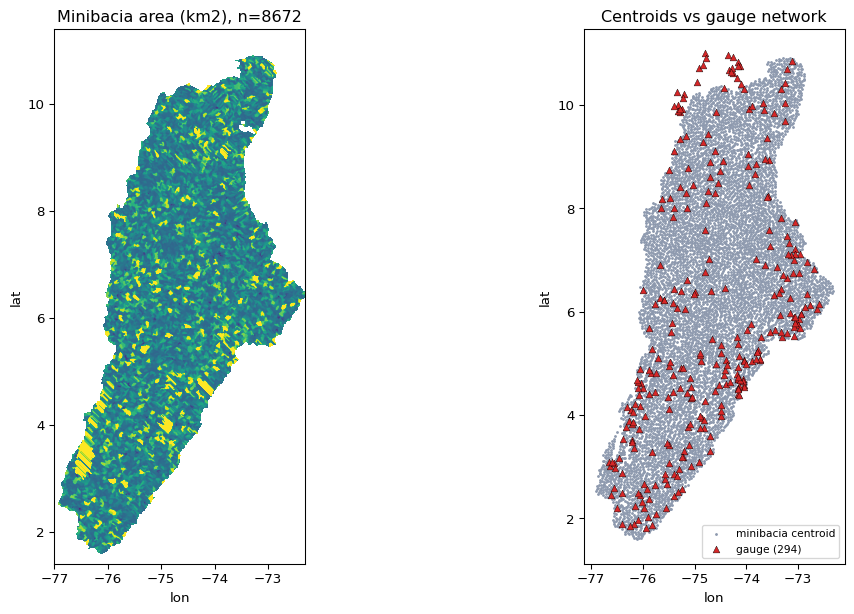

In [4]:
ids = mb.id.values
com = ndimage.center_of_mass(np.ones_like(lab, dtype=np.uint8), lab, ids)
cent = pd.DataFrame({
    'id': ids,
    'lon': tr.c + (np.array([c[1] for c in com]) + 0.5)*tr.a,
    'lat': tr.f + (np.array([c[0] for c in com]) + 0.5)*tr.e,
    'area_km2': mb.area_km2.values}).dropna(subset=['lon', 'lat']).reset_index(drop=True)
print(f'centroids: {len(cent)} of {len(ids)}')

fig, ax = plt.subplots(1, 2, figsize=(13, 6.5))
ax[0].imshow(to_grid(cent.id, cent.area_km2), extent=EXT, origin='upper',
             cmap='viridis', vmin=0, vmax=np.percentile(cent.area_km2, 98))
ax[0].set_title(f'Minibacia area (km2), n={len(cent)}'); ax[0].set_xlabel('lon'); ax[0].set_ylabel('lat')
ax[1].scatter(cent.lon, cent.lat, s=1.2, c='#8d99ae', label='minibacia centroid')
ax[1].scatter(gauges.lon, gauges.lat, s=26, c='#d62728', marker='^',
              edgecolor='k', lw=.3, label=f'gauge ({len(gauges)})')
ax[1].set_title('Centroids vs gauge network'); ax[1].legend(fontsize=8)
ax[1].set_xlabel('lon'); ax[1].set_ylabel('lat'); ax[1].set_aspect('equal')
plt.tight_layout(); plt.show()

## 3 - Gauge to minibacia interpolation (IDW, masked, with adaptive fallback)

Inverse-distance weighting on the nearest gauges. For minibacia *i* on day *t*:

$$P_{i,t}=\frac{\sum_{j\in N_i} w_{ij}\,\delta_{j,t}\,P_{j,t}}{\sum_{j\in N_i} w_{ij}\,\delta_{j,t}},
\qquad w_{ij}=\frac{1}{d_{ij}^{2}},\qquad
\delta_{j,t}=\begin{cases}1 & \text{gauge } j \text{ reported on day } t\\ 0 & \text{otherwise}\end{cases}$$

**The $\delta_{j,t}$ mask is the part that quietly ruins this if omitted.** The gauge matrix is only
~58 % filled. With fixed weights a missing gauge either propagates NaN or contributes an implicit
zero and silently drags the estimate down. The denominator must be recomputed every day over the
gauges that actually reported.

**Why the station series are not gap-filled first.** Imputing a station's missing day from its
neighbours and then treating that value as an observation double-counts the neighbours' information
and makes the field look better constrained than it is. The masked weighted mean does the same job
honestly, at the point of use.

**Adaptive fallback.** With $k=6$, some minibacia-days still come out NaN because all six nearest
gauges were silent. MGB cannot accept NaN, so a second pass over $k=20$ fills only those cells. The
tight $k=6$ behaviour is preserved everywhere else, and the number of fallback cells is reported -
they are lower-confidence by construction.

In [5]:
def km(la1, lo1, la2, lo2):
    return np.sqrt(((la1-la2)*111.0)**2
                   + ((lo1-lo2)*111.0*np.cos(np.radians((la1+la2)/2)))**2)

G = W.copy()                                  # days x gauges (from the QC section)
dates = G.index
Gv = G.values.astype('float32')
obs = ~np.isnan(Gv)
Gf = np.where(obs, Gv, 0.0).astype('float32')

D = km(cent.lat.values[:, None], cent.lon.values[:, None],
       gauges.lat.values[None, :], gauges.lon.values[None, :])
srt = np.argsort(D, axis=1)

def idw(k):
    nb = srt[:, :k]
    dkm = np.take_along_axis(D, nb, 1)
    wt = (1.0/np.maximum(dkm, 1.0)**2).astype('float32')
    out = np.full((len(dates), len(cent)), np.nan, dtype='float32')
    for a in range(0, len(cent), 500):
        b = min(a+500, len(cent))
        i2, w2 = nb[a:b], wt[a:b]
        num = (Gf[:, i2]*w2).sum(2)
        den = (obs[:, i2]*w2).sum(2)
        with np.errstate(invalid='ignore', divide='ignore'):
            out[:, a:b] = np.where(den > 0, num/den, np.nan)
    return out, dkm

P, dk6 = idw(6)
gap = np.isnan(P)
n_gap = int(gap.sum())
if n_gap:
    P20, _ = idw(20)
    P = np.where(gap, P20, P)
filled = int(n_gap - np.isnan(P).sum())

print(f'forcing matrix: {P.shape[0]} days x {P.shape[1]} minibacias')
print(f'  k=6 NaN cells        : {n_gap:,} ({100*n_gap/P.size:.3f} %)')
print(f'  filled by k=20 pass  : {filled:,}')
print(f'  remaining NaN        : {int(np.isnan(P).sum()):,}')
print(f'  basin-mean rainfall  : {np.nanmean(P):.2f} mm/day ({365.25*np.nanmean(P):.0f} mm/yr)')
cent['fallback_days'] = gap.sum(0)

forcing matrix: 4018 days x 8672 minibacias
  k=6 NaN cells        : 118,124 (0.339 %)
  filled by k=20 pass  : 118,124
  remaining NaN        : 0


  basin-mean rainfall  : 6.04 mm/day (2206 mm/yr)


## 4 - What the rainfall field looks like

Four views, because a single number cannot show whether an interpolated field is sensible: one wet
day (does it look like weather, or like a set of bullseyes around gauges?), the long-term mean (does
it reproduce the known orographic pattern?), the seasonal cycle (does it show the Magdalena's bimodal
regime?), and the basin-mean series (are the ENSO years visible?).

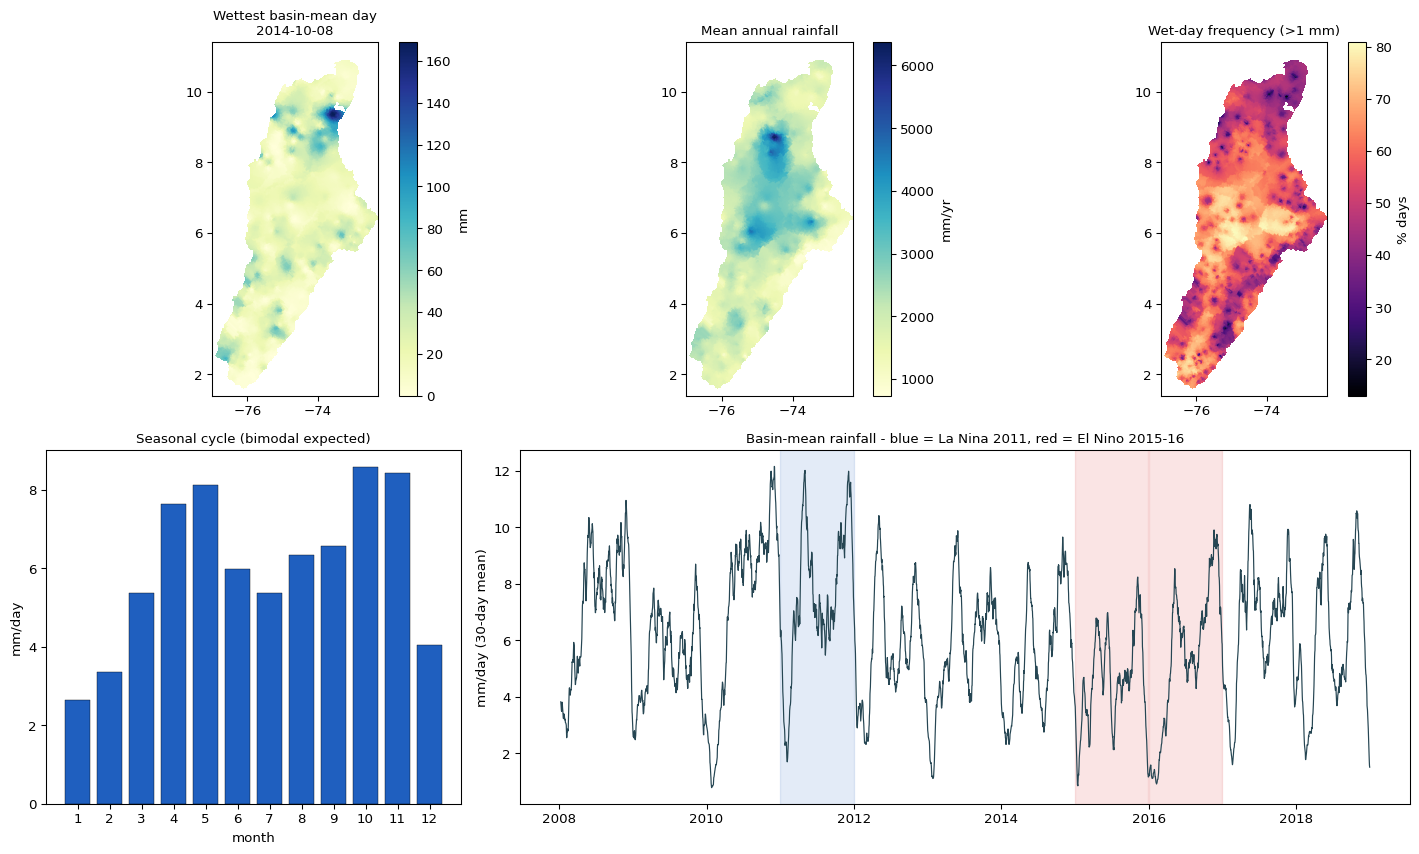

annual rainfall range across minibacias: 734 - 6371 mm/yr
seasonal cycle: driest month 1 (2.7), wettest 10 (8.6 mm/day)


In [6]:
Pdf = pd.DataFrame(P, index=dates, columns=cent.id.values)
basin_mean = Pdf.mean(1)
wettest = basin_mean.idxmax()

fig = plt.figure(figsize=(15, 9))
a1 = fig.add_subplot(2, 3, 1)
im = a1.imshow(to_grid(cent.id, Pdf.loc[wettest].values), extent=EXT, origin='upper', cmap='YlGnBu')
plt.colorbar(im, ax=a1, label='mm'); a1.set_title(f'Wettest basin-mean day\n{wettest.date()}', fontsize=10)

a2 = fig.add_subplot(2, 3, 2)
ann = Pdf.mean(0).values*365.25
im = a2.imshow(to_grid(cent.id, ann), extent=EXT, origin='upper', cmap='YlGnBu')
plt.colorbar(im, ax=a2, label='mm/yr'); a2.set_title('Mean annual rainfall', fontsize=10)

a3 = fig.add_subplot(2, 3, 3)
im = a3.imshow(to_grid(cent.id, (Pdf > 1).mean(0).values*100), extent=EXT, origin='upper', cmap='magma')
plt.colorbar(im, ax=a3, label='% days'); a3.set_title('Wet-day frequency (>1 mm)', fontsize=10)

a4 = fig.add_subplot(2, 3, 4)
clim_m = basin_mean.groupby(basin_mean.index.month).mean()
a4.bar(clim_m.index, clim_m.values, color='#1f5fbf', edgecolor='k', lw=.3)
a4.set_xticks(range(1, 13)); a4.set_xlabel('month'); a4.set_ylabel('mm/day')
a4.set_title('Seasonal cycle (bimodal expected)', fontsize=10)

a5 = fig.add_subplot(2, 3, (5, 6))
a5.plot(basin_mean.index, basin_mean.rolling(30, min_periods=10).mean(), lw=.9, color='#264653')
for yr, c in [(2011, '#1f5fbf'), (2015, '#d62728'), (2016, '#d62728')]:
    a5.axvspan(pd.Timestamp(yr, 1, 1), pd.Timestamp(yr, 12, 31), color=c, alpha=.12)
a5.set_ylabel('mm/day (30-day mean)'); a5.set_title('Basin-mean rainfall - blue = La Nina 2011, red = El Nino 2015-16', fontsize=10)
plt.tight_layout(); plt.show()

print(f'annual rainfall range across minibacias: {ann.min():.0f} - {ann.max():.0f} mm/yr')
print(f'seasonal cycle: driest month {clim_m.idxmin()} ({clim_m.min():.1f}), '
      f'wettest {clim_m.idxmax()} ({clim_m.max():.1f} mm/day)')

## 5 - Provenance flags: which minibacias are measured, and which are inferred

The most important column in the output. It is what lets the final report state *which* parts of the
sediment signal rest on measurements and which rest on extrapolation.

| Flag | Distance to nearest gauge | Interpretation |
|---|---|---|
| `G` | < 10 km | measurement-dominated |
| `GC` | 10-30 km | interpolated, gauge-constrained |
| `C` | > 30 km | extrapolated - no local measurement |

      minibacias  area_km2  median_dist_km  pct_area
flag                                                
G           2213   66443.0             6.6      25.8
GC          4963  146721.2            17.4      57.1
C           1496   43932.8            38.2      17.1

basin area with no local measurement (flag C): 17.1 %


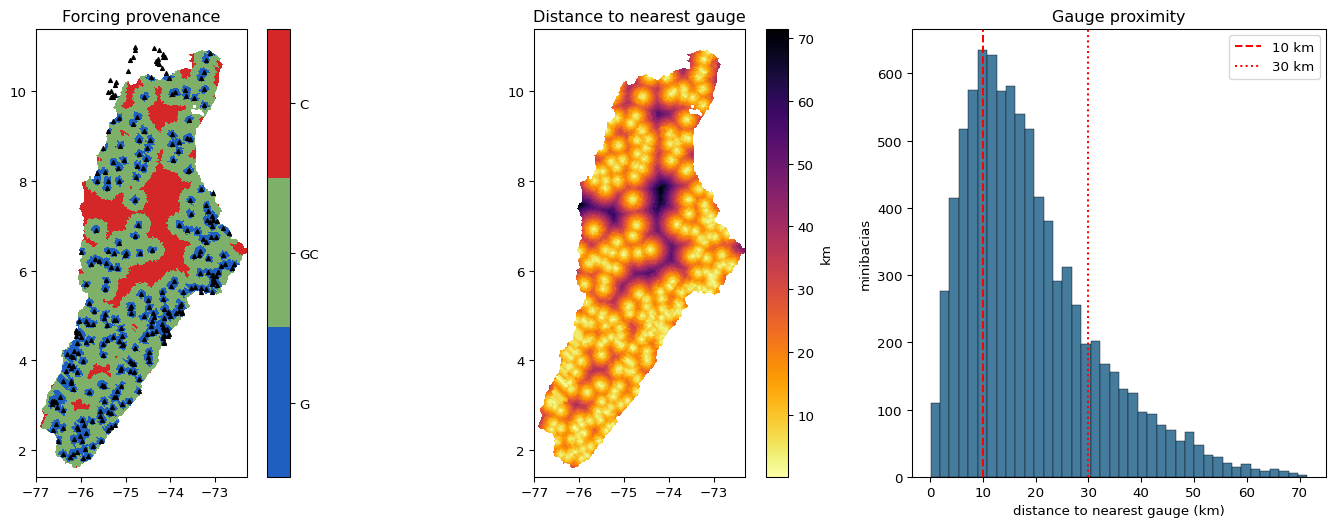

In [7]:
cent['d_nearest_km'] = dk6[:, 0]
cent['flag'] = np.where(cent.d_nearest_km < 10, 'G',
                np.where(cent.d_nearest_km <= 30, 'GC', 'C'))
summary = (cent.groupby('flag')
              .agg(minibacias=('id', 'size'), area_km2=('area_km2', 'sum'),
                   median_dist_km=('d_nearest_km', 'median'))
              .reindex(['G', 'GC', 'C']))
summary['pct_area'] = 100*summary.area_km2/cent.area_km2.sum()
print(summary.round(1).to_string())
print(f"\nbasin area with no local measurement (flag C): {summary.loc['C','pct_area']:.1f} %")

fcode = cent.flag.map({'G': 0, 'GC': 1, 'C': 2}).values
fig, ax = plt.subplots(1, 3, figsize=(15, 5.6))
from matplotlib.colors import ListedColormap
im = ax[0].imshow(to_grid(cent.id, fcode), extent=EXT, origin='upper',
                  cmap=ListedColormap(['#1f5fbf', '#7fb069', '#d62728']), vmin=0, vmax=2)
ax[0].scatter(gauges.lon, gauges.lat, s=8, c='k', marker='^')
cb = plt.colorbar(im, ax=ax[0], ticks=[0.33, 1, 1.67]); cb.ax.set_yticklabels(['G', 'GC', 'C'])
ax[0].set_title('Forcing provenance')
im = ax[1].imshow(to_grid(cent.id, cent.d_nearest_km), extent=EXT, origin='upper', cmap='inferno_r')
plt.colorbar(im, ax=ax[1], label='km'); ax[1].set_title('Distance to nearest gauge')
ax[2].hist(cent.d_nearest_km, bins=40, color='#457b9d', edgecolor='k', lw=.3)
for x, ls in [(10, '--'), (30, ':')]:
    ax[2].axvline(x, color='r', ls=ls, label=f'{x} km')
ax[2].set_xlabel('distance to nearest gauge (km)'); ax[2].set_ylabel('minibacias')
ax[2].set_title('Gauge proximity'); ax[2].legend()
plt.tight_layout(); plt.show()

## 6 - Leave-one-out cross-validation, and the spatial-consistency check

Each gauge is removed in turn, its value predicted from the remaining gauges by the same IDW scheme,
and compared with what it actually recorded. This is the baseline skill a CHIRPS-merged v2 must beat
to justify its complexity.

Reported **stratified by gauge isolation**, because the basin-wide average hides the thing that
matters: skill in sparsely gauged terrain is what decides whether the ungauged headwaters can be
trusted.

The same leave-one-out prediction doubles as the **spatial-consistency check** deferred from section 1
- a station-day whose observation is wildly inconsistent with every neighbour is a candidate error
that survived the 0-400 mm screen.

LOOCV over 288 gauges | daily r median 0.410 | bias +1.1 % | RMSE 11.2 mm/day

               r  bias_pct    rmse
isolation                         
<10 km     0.467     0.698  10.511
10-30 km   0.398    -0.383  11.144
>30 km     0.313     6.244  13.146

spatial-consistency: 2,700 suspect station-days (0.336 % of observations)


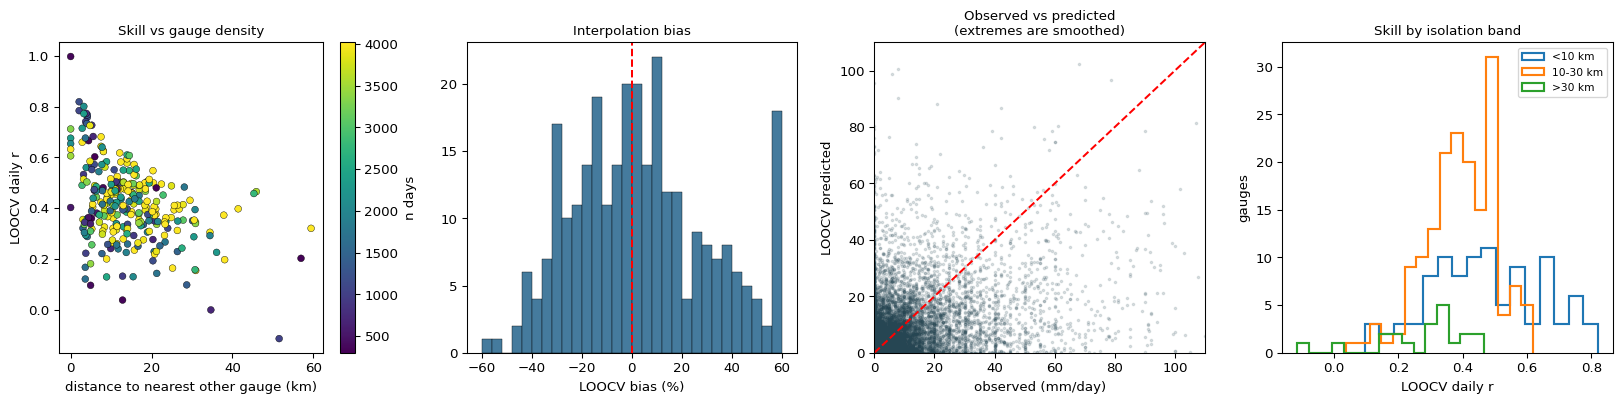

In [8]:
Dg = km(gauges.lat.values[:, None], gauges.lon.values[:, None],
        gauges.lat.values[None, :], gauges.lon.values[None, :])
np.fill_diagonal(Dg, np.inf)
gn = np.argsort(Dg, axis=1)[:, :6]
gdk = np.take_along_axis(Dg, gn, 1)
gW = (1.0/np.maximum(gdk, 1.0)**2).astype('float32')

pred = np.full(Gv.shape, np.nan, dtype='float32')
for j in range(len(gauges)):
    num = (Gf[:, gn[j]]*gW[j]).sum(1)
    den = (obs[:, gn[j]]*gW[j]).sum(1)
    with np.errstate(invalid='ignore', divide='ignore'):
        pred[:, j] = np.where(den > 0, num/den, np.nan)

ok = obs & ~np.isnan(pred)
rows = []
for j in range(len(gauges)):
    m = ok[:, j]
    if m.sum() < 300:
        continue
    o, p = Gv[m, j], pred[m, j]
    rows.append({'code': gauges.code.iloc[j], 'n': int(m.sum()),
                 'r': float(np.corrcoef(o, p)[0, 1]),
                 'bias_pct': 100*(p.sum()/o.sum()-1) if o.sum() > 0 else np.nan,
                 'rmse': float(np.sqrt(((p-o)**2).mean())),
                 'd_nearest_km': float(gdk[j, 0])})
loo = pd.DataFrame(rows)
loo['isolation'] = pd.cut(loo.d_nearest_km, [0, 10, 30, 1e9], labels=['<10 km', '10-30 km', '>30 km'])
print(f'LOOCV over {len(loo)} gauges | daily r median {loo.r.median():.3f} | '
      f'bias {loo.bias_pct.median():+.1f} % | RMSE {loo.rmse.median():.1f} mm/day\n')
print(loo.groupby('isolation', observed=True)[['r', 'bias_pct', 'rmse']].median().round(3).to_string())

resid = np.where(ok, Gv-pred, np.nan)
susp = np.abs(resid) > np.maximum(60.0, 6*np.where(np.isnan(pred), np.nan, pred))
print(f'\nspatial-consistency: {int(np.nansum(susp)):,} suspect station-days '
      f'({100*np.nansum(susp)/ok.sum():.3f} % of observations)')

fig, ax = plt.subplots(1, 4, figsize=(17, 4.3))
sc = ax[0].scatter(loo.d_nearest_km, loo.r, s=26, c=loo.n, cmap='viridis', edgecolor='k', lw=.3)
plt.colorbar(sc, ax=ax[0], label='n days')
ax[0].set_xlabel('distance to nearest other gauge (km)'); ax[0].set_ylabel('LOOCV daily r')
ax[0].set_title('Skill vs gauge density', fontsize=10)
ax[1].hist(loo.bias_pct.clip(-60, 60), bins=30, color='#457b9d', edgecolor='k', lw=.3)
ax[1].axvline(0, color='r', ls='--'); ax[1].set_xlabel('LOOCV bias (%)'); ax[1].set_title('Interpolation bias', fontsize=10)
sub = np.random.RandomState(0).choice(np.flatnonzero(ok.ravel()), 20000, replace=False)
ax[2].scatter(Gv.ravel()[sub], pred.ravel()[sub], s=3, alpha=.15, c='#264653')
lim = [0, np.nanpercentile(Gv, 99.9)]
ax[2].plot(lim, lim, 'r--'); ax[2].set_xlim(lim); ax[2].set_ylim(lim)
ax[2].set_xlabel('observed (mm/day)'); ax[2].set_ylabel('LOOCV predicted')
ax[2].set_title('Observed vs predicted\n(extremes are smoothed)', fontsize=10)
for lbl, g in loo.groupby('isolation', observed=True):
    ax[3].hist(g.r.dropna(), bins=16, histtype='step', lw=1.6, label=str(lbl))
ax[3].set_xlabel('LOOCV daily r'); ax[3].set_ylabel('gauges'); ax[3].legend(fontsize=8)
ax[3].set_title('Skill by isolation band', fontsize=10)
plt.tight_layout(); plt.show()

## 7 - PET: FAO-56 Penman-Monteith from ERA5-Land

$$ET_0=\frac{0.408\,\Delta\,(R_n-G)+\gamma\frac{900}{T+273}u_2(e_s-e_a)}{\Delta+\gamma(1+0.34u_2)}$$

Computed on the ERA5 grid (~0.1 deg) and assigned to minibacias by nearest cell. ERA5's resolution is
coarser than a minibacia, so interpolating first would invent detail the reanalysis does not contain.
This asymmetry with rainfall is physical, not a shortcut: PET is driven by radiation and temperature
and varies smoothly, whereas rainfall is spatially erratic and needs dense point measurements.

**Two ERA5 traps handled explicitly:**

1. **The time coordinate is `valid_time`, not `time`** - and `number`/`expver` are scalar *coords*,
   not dims, so they need `drop_vars` rather than `isel`.
2. **`ssrd` is an accumulation, not a flux**, and its daily total is subtler than it first appears.
   ERA5-Land accumulates from 00 UTC and resets, so summing hourly values over-counts radiation
   roughly tenfold and inflates PET to ~30 mm/day. The running maximum is closer - but still wrong,
   because the 00:00 stamp carries the **previous** day's completed total. A plain max over the UTC
   day therefore returns yesterday's figure whenever yesterday was sunnier, inflating radiation by
   ~7 %. Inspecting the raw hourly series makes it obvious:

   ```
   01-01 00:00 : 18.68 MJ   <- the whole of 31 Dec
   01-01 01:00 :  0.00      <- accumulation restarts
   01-01 23:00 : 20.35      <- the real total for 01 Jan
   01-02 00:00 : 20.35      <- carried into the next day
   ```

   The fix is to exclude hour 0 and take the maximum over 01:00-23:00. Worth noting that the
   18-22 MJ/m2/day sanity check does *not* catch this: the inflated 19.1 sits comfortably inside the
   plausible band. Only comparing aggregation methods against the raw series exposed it.

Elevation for the clear-sky term comes from ERA5 surface pressure via the barometric formula,
avoiding a 244 MB DEM read for a second-order correction.

In [9]:
ext = sorted(glob.glob(str(clim/'era5land_ext_*.nc')))
print(f'ERA5 mosaicked files available: {len(ext)} / 108')
PET_READY = len(ext) >= 108
if not PET_READY:
    print('  -> incomplete; run  python src/mosaic_era5.py  then re-run. Sections 1-6 are unaffected.')

ERA5 mosaicked files available: 108 / 108


ERA5 daily: {'time': 3287, 'latitude': 101, 'longitude': 48}
  radiation rs : 17.2 MJ/m2/day   [sanity: 18-22 in the tropics]


  PET          : 3.40 mm/day  (p1-p99 1.3-5.8)   [sanity: 3-5]


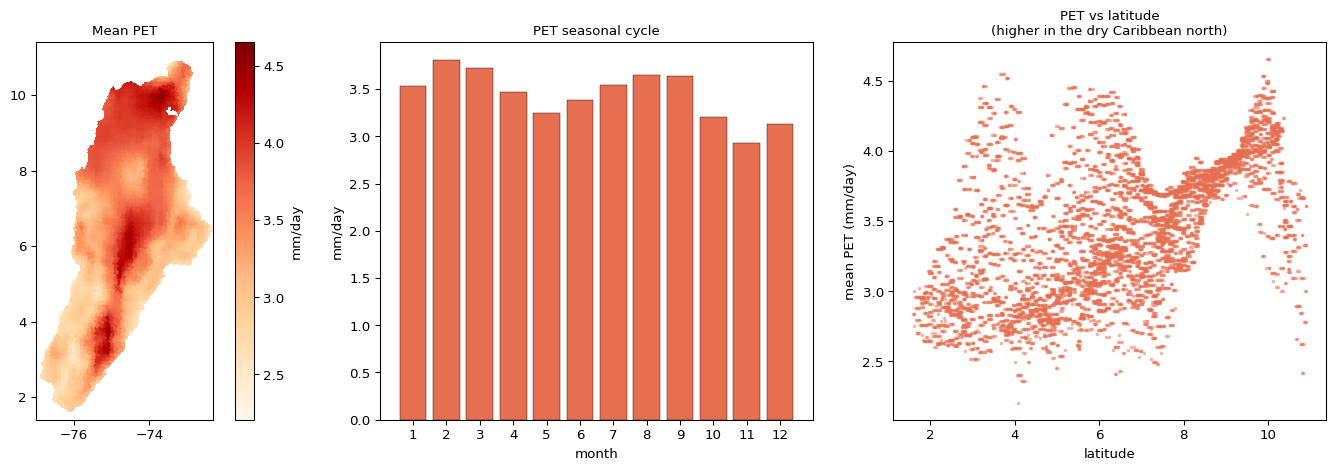

In [10]:
def esat(t_c):
    return 0.6108*np.exp(17.27*t_c/(t_c+237.3))


def et0_fao56(tmean, tmax, tmin, tdew, rs, wind10, sp_pa, lat_deg, doy):
    '''FAO-56 Penman-Monteith reference ET, mm/day. rs in MJ/m2/day, sp in Pa.'''
    u2 = wind10*4.87/np.log(67.8*10-5.42)
    gamma = 0.000665*(sp_pa/1000.0)
    es = (esat(tmax)+esat(tmin))/2.0
    ea = esat(tdew)
    delta = 4098*esat(tmean)/(tmean+237.3)**2
    phi = np.radians(lat_deg)
    dr = 1+0.033*np.cos(2*np.pi*doy/365.0)
    dec = 0.409*np.sin(2*np.pi*doy/365.0-1.39)
    ws = np.arccos(np.clip(-np.tan(phi)*np.tan(dec), -1, 1))
    ra = (24*60/np.pi)*0.0820*dr*(ws*np.sin(phi)*np.sin(dec)
                                  + np.cos(phi)*np.cos(dec)*np.sin(ws))
    z = 44330.0*(1-(sp_pa/101325.0)**0.1903)
    rso = (0.75+2e-5*z)*ra
    rns = (1-0.23)*rs
    rnl = (4.903e-9*((tmax+273.16)**4+(tmin+273.16)**4)/2
           * (0.34-0.14*np.sqrt(np.maximum(ea, 0)))
           * np.clip(1.35*rs/np.maximum(rso, 1e-6)-0.35, 0, 1))
    num = 0.408*delta*(rns-rnl) + gamma*(900/(tmean+273))*u2*np.maximum(es-ea, 0)
    return np.maximum(num/(delta+gamma*(1+0.34*u2)), 0)


if PET_READY:
    import xarray as xr
    frames = []
    for f in ext:
        with xr.open_dataset(f) as d:
            d = d.rename({'valid_time': 'time'})
            for c in ('number', 'expver'):
                if c in d.dims:
                    d = d.isel({c: 0}, drop=True)
                elif c in d.coords:
                    d = d.drop_vars(c)
            tc = d['t2m']-273.15
            wind = np.sqrt(d['u10']**2+d['v10']**2)
            g = d.time.dt.floor('D')
            # ssrd accumulates from 00 UTC and resets. The 00:00 stamp still carries the
            # PREVIOUS day's full total, so a plain max over the day picks that up whenever
            # yesterday was sunnier - inflating radiation ~7 %. Exclude hour 0; the running
            # max over 01:00-23:00 is the day's own total.
            ssrd = d['ssrd'].where(d['ssrd'].time.dt.hour != 0)
            agg = xr.Dataset({
                'tmean': tc.groupby(g).mean('time'), 'tmax': tc.groupby(g).max('time'),
                'tmin': tc.groupby(g).min('time'), 'tdew': (d['d2m']-273.15).groupby(g).mean('time'),
                'rs': ssrd.groupby(g).max('time')/1e6,
                'wind': wind.groupby(g).mean('time'), 'sp': d['sp'].groupby(g).mean('time')})
            dn = [x for x in agg.dims if x not in ('latitude', 'longitude')][0]
            frames.append(agg.rename({dn: 'time'}))
    E = xr.concat(frames, dim='time').sortby('time')
    lat2d = (E.latitude.values[:, None]*np.ones((1, E.longitude.size)))[None, :, :]
    doy = E.time.dt.dayofyear.values[:, None, None]
    pet = et0_fao56(E.tmean.values, E.tmax.values, E.tmin.values, E.tdew.values,
                    E.rs.values, E.wind.values, E.sp.values, lat2d, doy)

    print(f'ERA5 daily: {dict(E.sizes)}')
    print(f'  radiation rs : {float(E.rs.mean()):.1f} MJ/m2/day   [sanity: 18-22 in the tropics]')
    print(f'  PET          : {np.nanmean(pet):.2f} mm/day  '
          f'(p1-p99 {np.nanpercentile(pet,1):.1f}-{np.nanpercentile(pet,99):.1f})   [sanity: 3-5]')

    iy = np.abs(E.latitude.values[None, :]-cent.lat.values[:, None]).argmin(1)
    ix = np.abs(E.longitude.values[None, :]-cent.lon.values[:, None]).argmin(1)
    PETdf = pd.DataFrame(pet[:, iy, ix], index=pd.to_datetime(E.time.values), columns=cent.id.values)
    pet_mean = PETdf.mean(1)

    fig, ax = plt.subplots(1, 3, figsize=(15.5, 5))
    im = ax[0].imshow(to_grid(cent.id, PETdf.mean(0).values), extent=EXT, origin='upper', cmap='OrRd')
    plt.colorbar(im, ax=ax[0], label='mm/day'); ax[0].set_title('Mean PET', fontsize=10)
    pc = pet_mean.groupby(pet_mean.index.month).mean()
    ax[1].bar(pc.index, pc.values, color='#e76f51', edgecolor='k', lw=.3)
    ax[1].set_xticks(range(1, 13)); ax[1].set_xlabel('month'); ax[1].set_ylabel('mm/day')
    ax[1].set_title('PET seasonal cycle', fontsize=10)
    ax[2].scatter(cent.lat, PETdf.mean(0).values, s=3, c='#e76f51', alpha=.4)
    ax[2].set_xlabel('latitude'); ax[2].set_ylabel('mean PET (mm/day)')
    ax[2].set_title('PET vs latitude\n(higher in the dry Caribbean north)', fontsize=10)
    plt.tight_layout(); plt.show()

## 8 - Water balance and the ENSO contrast

The first place the two fields meet. Two things to check:

1. **Is $P-PET$ physically plausible?** The Magdalena is a wet basin, so rainfall should exceed
   atmospheric demand over the year, with a deficit in the dry season. A persistently negative annual
   balance would mean one of the two fields is wrong.
2. **Is the ENSO contrast present?** 2011 (La Nina) should be wetter *and* have lower PET; 2015-16
   (El Nino) drier *and* higher PET. Both terms push the same way, which is why the soil-moisture and
   runoff contrast is larger than the rainfall contrast alone - and why holding PET fixed would lose
   half the signal.

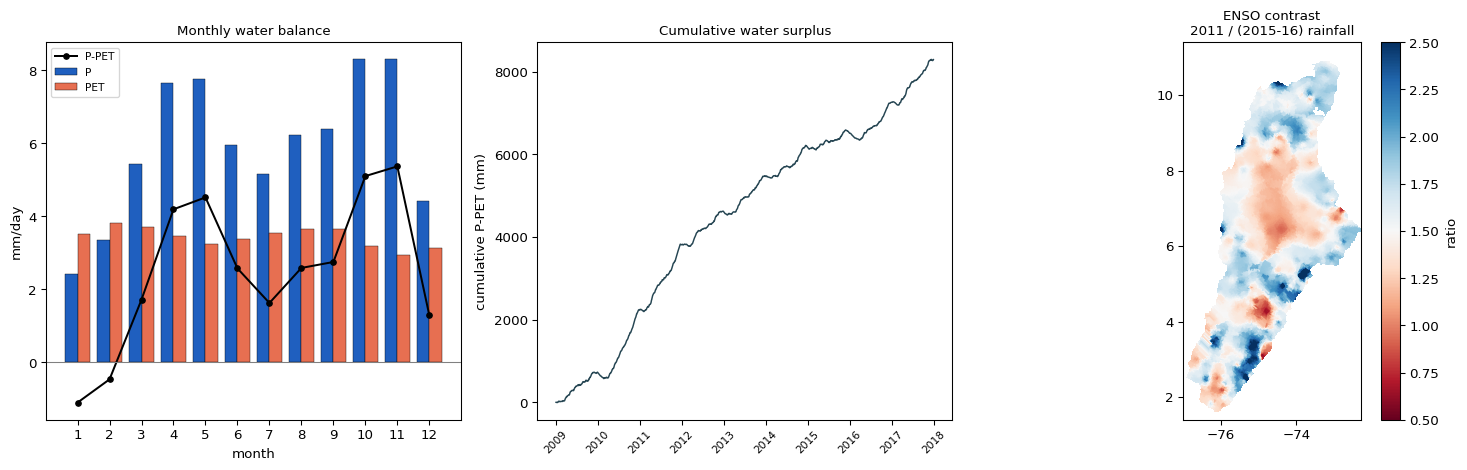

annual P 2176 mm | PET 1255 mm | surplus 922 mm/yr
median ENSO rainfall ratio across minibacias: 1.54x
  minibacias wetter in 2011: 98 %
PET 2011 1167 mm/yr  vs  2015-16 1303 mm/yr   (El Nino should be higher)


In [11]:
if PET_READY:
    common = Pdf.index.intersection(PETdf.index)
    Pc, Ec = Pdf.loc[common], PETdf.loc[common]
    p_m, e_m = Pc.mean(1), Ec.mean(1)
    mc = pd.DataFrame({'P': p_m.groupby(p_m.index.month).mean(),
                       'PET': e_m.groupby(e_m.index.month).mean()})

    wet = Pc[Pc.index.year == 2011].mean(0)
    dry = Pc[Pc.index.year.isin([2015, 2016])].mean(0)
    ratio = (wet/dry.replace(0, np.nan)).values

    fig, ax = plt.subplots(1, 3, figsize=(15.5, 5))
    x = np.arange(1, 13)
    ax[0].bar(x-.2, mc.P, .4, label='P', color='#1f5fbf', edgecolor='k', lw=.3)
    ax[0].bar(x+.2, mc.PET, .4, label='PET', color='#e76f51', edgecolor='k', lw=.3)
    ax[0].plot(x, mc.P-mc.PET, 'k-o', ms=4, label='P-PET')
    ax[0].axhline(0, color='grey', lw=.8); ax[0].set_xticks(x)
    ax[0].set_xlabel('month'); ax[0].set_ylabel('mm/day'); ax[0].legend(fontsize=8)
    ax[0].set_title('Monthly water balance', fontsize=10)

    ax[1].plot(common, (p_m-e_m).cumsum(), lw=1.1, color='#264653')
    ax[1].set_ylabel('cumulative P-PET (mm)'); ax[1].tick_params(axis='x', rotation=45, labelsize=8)
    ax[1].set_title('Cumulative water surplus', fontsize=10)

    im = ax[2].imshow(to_grid(cent.id, ratio), extent=EXT, origin='upper',
                      cmap='RdBu', vmin=0.5, vmax=2.5)
    plt.colorbar(im, ax=ax[2], label='ratio'); ax[2].set_title('ENSO contrast\n2011 / (2015-16) rainfall', fontsize=10)
    plt.tight_layout(); plt.show()

    print(f'annual P {365.25*p_m.mean():.0f} mm | PET {365.25*e_m.mean():.0f} mm | '
          f'surplus {365.25*(p_m-e_m).mean():.0f} mm/yr')
    print(f'median ENSO rainfall ratio across minibacias: {np.nanmedian(ratio):.2f}x')
    print(f'  minibacias wetter in 2011: {100*np.nanmean(ratio>1):.0f} %')
    print(f'PET 2011 {365.25*e_m[e_m.index.year==2011].mean():.0f} mm/yr  vs  '
          f'2015-16 {365.25*e_m[e_m.index.year.isin([2015,2016])].mean():.0f} mm/yr'
          '   (El Nino should be higher)')

## 9 - Export the MGB forcing tables

In [12]:
Pdf.index.name = 'date'
Pdf.to_csv(proc/'forcing_minibacia_precip.csv', float_format='%.2f')
cent.to_csv(proc/'forcing_minibacia_provenance.csv', index=False)
print(f'forcing_minibacia_precip.csv      {Pdf.shape[0]} days x {Pdf.shape[1]} minibacias')
print(f'forcing_minibacia_provenance.csv  {len(cent)} rows  '
      f'(cols: {", ".join(cent.columns)})')
if PET_READY:
    PETdf.index.name = 'date'
    PETdf.to_csv(proc/'forcing_minibacia_pet.csv', float_format='%.2f')
    print(f'forcing_minibacia_pet.csv         {PETdf.shape[0]} days x {PETdf.shape[1]} minibacias')
    print(f'\nmodel period (P and PET both available): '
          f'{common.min().date()} -> {common.max().date()}  ({len(common)} days)')

forcing_minibacia_precip.csv      4018 days x 8672 minibacias
forcing_minibacia_provenance.csv  8672 rows  (cols: id, lon, lat, area_km2, fallback_days, d_nearest_km, flag)


forcing_minibacia_pet.csv         3287 days x 8672 minibacias

model period (P and PET both available): 2009-01-01 -> 2017-12-31  (3287 days)


## Summary, and what this does not yet do

**Produced:** per-minibacia daily rainfall with no residual gaps, a provenance flag per minibacia,
a measured cross-validation baseline, Penman-Monteith PET, and a first water-balance check.

**Known limitations, stated rather than buried:**

1. **The ungauged 17 %.** Flag `C` minibacias are extrapolated. Section 6 quantifies the cost: in the
   `>30 km` band, daily *r* falls to ~0.27 and bias rises to ~+12 %, against ~0.45 and ~+1 % where
   gauges are dense. That is the specific, measured case for adding CHIRPS to those minibacias.
2. **Period mismatch.** Gauges span 2008-2018, ERA5-Land 2009-2017. The model run is bounded to
   **2009-2017** by PET, not by rainfall.
3. **`dia pluviometrico` offset.** Gauge days run 07:00->07:00 local; discharge is very likely
   midnight->midnight. Notebook 10's lag test showed a one-day realignment doubles the CHIRPS-gauge
   correlation (0.14 -> 0.29), confirming the convention is real and material. It does not affect
   gauge-only interpolation - all gauges share it - but it **must** be resolved before calibrating
   against hydrographs, or the routing and recession parameters will absorb a ~7 h timing error and
   appear well calibrated for the wrong reason.
4. **No orographic correction.** Plain IDW ignores elevation, so headwater rainfall is interpolated
   from lower stations with no lapse adjustment. The observed-vs-predicted panel in section 6 shows
   the related weakness directly: interpolation smooths extremes.
5. **Fallback cells are lower confidence.** Where all six nearest gauges were silent, the estimate
   comes from up to 20 gauges and is correspondingly weaker. Counted per minibacia in
   `fallback_days`.

**Next:** v2 forcing - quantile-map CHIRPS onto these gauges, merge conditionally, and re-run
section 6's LOOCV to test whether it actually beats the baseline measured here.